<a href="https://colab.research.google.com/github/Nethika-Alagarathnam/AnimatedSite/blob/main/Detecting_AI_generated_Short_Responses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets scikit-learn nltk spacy tqdm
!python -m spacy download en_core_web_sm

import nltk
nltk.download('punkt')
nltk.download('stopwords')

print("Setup complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Setup complete!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def generate_ai_text(prompt, max_len=80):
    inputs = tokenizer(prompt, return_tensors='pt', padding=True).to("cuda")
    outputs = model.generate(
        **inputs,
        max_length=max_len,
        temperature=0.7,
        do_sample=True,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

def clean_ai_text(text):

    text = text.replace("Explain briefly:", "")
    text = text.replace("Explain this topic briefly:", "")
    text = text.replace("\n", " ")
    return text.strip()


def is_valid_length(text, min_words=5, max_words=15):

    word_count = len(text.split())
    return min_words <= word_count <= max_words

def generate_ai_text(prompt="Explain briefly:", max_len=40):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_length=max_len,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return clean_ai_text(text)

ai_texts = []

for i in range(1000):
    ai_texts.append(generate_ai_text("Explain this topic briefly:"))

    if (i + 1) % 100 == 0:
        print(f"Generated {i+1}/1000 AI samples")

print("\nAI generation complete!")
print("Total AI samples:", len(ai_texts))
print("Example AI samples:\n", ai_texts[:3])


Generated 100/1000 AI samples
Generated 200/1000 AI samples
Generated 300/1000 AI samples
Generated 400/1000 AI samples
Generated 500/1000 AI samples
Generated 600/1000 AI samples
Generated 700/1000 AI samples
Generated 800/1000 AI samples
Generated 900/1000 AI samples
Generated 1000/1000 AI samples

AI generation complete!
Total AI samples: 1000
Example AI samples:
 ['the purpose of this project was to create a web app that can handle multiple user input.  As an example, the following example shows how to use the command line', 'You can use this topic to get a general idea of the various techniques you can use in order to apply your skills and knowledge to your work.  You', "I'm not going to go into specifics, but the gist is that you have to define your content in a way that looks like this:  # This"]


In [ ]:
import random

human_patterns = [
    "AI can't replace human and I hope so",
    "When we are writing research papers we have to consider about plagiarism.",
    "Instead of going outside I would prefer staying at home these days.",
    "After finish writing the full paper, we have to start writing abstract.",
    "This mini project demonstrates how ML and other techniques can classify Turkish raisin varieties.",
    "Traditional selection processes for internships often face challenges.",
    "MySQL is a query based database system.",
    "I'm Nethika, who is passionate in lecturing and doing research.",
    "I love travelling and exploring new things.",
    "I came here to partcipate in the conference.",
    "Yesterday, I and my friends went to donate blood.",
    "I fainted when I'm giving blood.",
    "An opportunity to gain support.",
    "My friend selected as the probationary lecturer at Vavuniya University.",
    "Sri Lanka is facing major problems during the bad weather condition.",
    "Because of heavy rain people died.",
    "I love to be in university of peradeniya, because of it's atmosphere.",
    "Wiraj drive the car to pizza hut.",
    "I went to the market today and forgot half the things I needed.",
    "My friend called me this morning and we talked for almost an hour.",
    "I was so tired today that I slept through my alarm.",
    "I made tea and then accidentally spilled it on my notebook.",
      "I stayed home because the weather was bad",
    "I tried studying but felt very distracted",
    "I was nervous before presenting my work",
    "I missed the lecture because I felt sick",
    "I enjoyed working on this small project",
    "I struggled to finish the assignment today",
    "I felt happy after completing my task",
    "I walked outside because the weather was too nice to stay indoors.",
    "I was trying to study but ended up scrolling on my phone.",
    "My mom asked me to buy bread but the shop was closed.",
    "I cooked rice today",
    "Skill mapping is the basic conversion method.",
    "I met my cousin after a long time and we had a great chat.",
    "I cleaned my room today but now it looks messy again.",
    "Please try to submit atleast an abstract",
    "Please join the meeting on poya day",
    "Have you ever think about visitng a temple?",
    "It's not a good time for a chat",
    "Wedenesday web series is one of my favourites",
    "Have you ever wonder about my skills?",
    "You know, I've participated in several interviews and got good comments, but still rejected.",
    "When you visited my CMT you can see only one accept and others reject.",
    "Rejection will make me more better even more better.",
    "I waited for the bus for 20 minutes and it still didn’t come.",
    "I forgot to bring my charger and my phone battery was dying.",
    "I ate too much today and now I feel sleepy.",
    "Dogs and cats are my world, but my mother is not fond of them.",
    "One day I'll adopt street dogs and I'll make a home to them.",
    "When I'm talking with GPT, I'm feeling happy because that LLM motivates me several time.",
    "Doing research on LLM is one of my aims.",
    "There are five more sentences to reach 50.",
    "You know there are fifteen days more to submit a paper.",
    "Still I didn't receive payment for the exam duty",
    "I tried to exercise today but gave up after 10 minutes.",
    "I was writing something and suddenly my pen stopped working."
]

def generate_human_texts(n=1000):
    human_texts = []
    while len(human_texts) < n:
        sentence = random.choice(human_patterns)

        variation = sentence + random.choice([
            "", ".", " today", " yesterday", " this morning"
        ])

        if 5 <= len(variation.split()) <= 15:
            human_texts.append(variation)

        if len(human_texts) % 100 == 0:
            print(f"Generated {len(human_texts)}/1000 human samples")

    return human_texts

human_texts = generate_human_texts()

print("\nHuman generation complete!")
print("Example human samples:\n", human_texts[:5])


Generated 100/1000 human samples
Generated 200/1000 human samples
Generated 300/1000 human samples
Generated 400/1000 human samples
Generated 500/1000 human samples
Generated 600/1000 human samples
Generated 700/1000 human samples
Generated 800/1000 human samples
Generated 900/1000 human samples
Generated 1000/1000 human samples

Human generation complete!
Example human samples:
 ['My friend selected as the probationary lecturer at Vavuniya University.', 'I ate too much today and now I feel sleepy. yesterday', 'Please try to submit atleast an abstract yesterday', "I'm Nethika, who is passionate in lecturing and doing research..", "I fainted when I'm giving blood."]


In [ ]:
import pandas as pd

print(len(ai_texts), len(human_texts))

data = pd.DataFrame({
    "text": ai_texts + human_texts,
    "label": ["AI"]*len(ai_texts) + ["Human"]*len(human_texts)
})

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data.to_csv("ai_vs_human_dataset.csv", index=False)

print(data.head())
print(data['label'].value_counts())


1000 1000
                                                text  label
0  Traditional selection processes for internship...  Human
1  Why are we seeing so many cases of "disappeare...     AI
2        I ate too much today and now I feel sleepy.  Human
3  Why do the "pilot's license" requirement apply...     AI
4  I ate too much today and now I feel sleepy. ye...  Human
label
Human    1000
AI       1000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

joblib.dump(clf, "ai_human_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved!")


Accuracy: 0.9975

Classification Report:
               precision    recall  f1-score   support

          AI       1.00      0.99      1.00       197
       Human       1.00      1.00      1.00       203

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

Model and vectorizer saved!


In [ ]:
import joblib

clf = joblib.load("ai_human_classifier.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

new_texts = [
    "I'm intersted to study but I'm feeling tired.",
    "Machine learning models analyze patterns in large datasets to generate accurate predictions"
]

new_tfidf = vectorizer.transform(new_texts)

predictions = clf.predict(new_tfidf)
for text, pred in zip(new_texts, predictions):
    print(f"Text: {text}\nPrediction: {pred}\n")


Text: I'm intersted to study but I'm feeling tired.
Prediction: Human

Text: Machine learning models analyze patterns in large datasets to generate accurate predictions
Prediction: AI



In [ ]:
y_train_pred = clf.predict(X_train_tfidf)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train Accuracy:", train_accuracy)

test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.9975


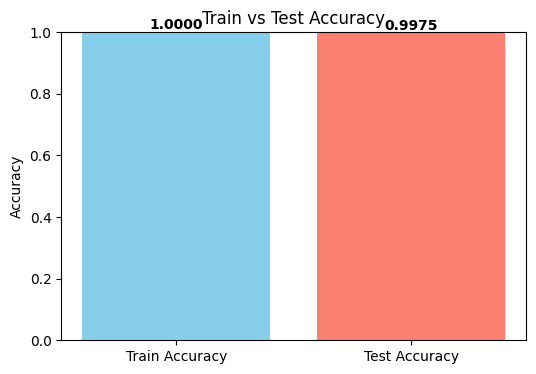

In [ ]:
import matplotlib.pyplot as plt

accuracies = [train_accuracy, test_accuracy]
labels = ["Train Accuracy", "Test Accuracy"]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracies, color=['skyblue','salmon'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

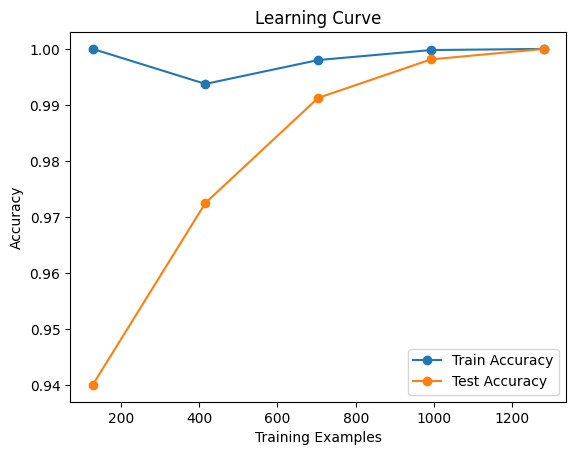

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train_tfidf, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train Accuracy", marker='o')
plt.plot(train_sizes, test_mean, label="Test Accuracy", marker='o')
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()